# ARIMA Model Testing

In [76]:
import itertools
import logging
import os
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')

sns.set_palette('colorblind')
warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)

mlflow.set_experiment('Brazil Tourism Forecasting ARIMA')

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1781132358379, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781132358379, lifecycle_stage='active', name='Brazil Tourism Forecasting ARIMA', tags={}, trace_location=None, workspace='default'>

## Data Preparation

Two training data selections will be evaluated in the grid search:

- **`last_10y_covid_exog`** — last 10 years of training data with a 0/1 COVID regressor to absorb the structural break
- **`post_covid`** — only post-COVID data (2022 onwards); no exog needed, cleaner signal

Evaluation metrics are computed on **test.parquet** (Jan–Jun 2025) for all models.

In [77]:
train_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))
train_monthly = train_df.set_index('date')[['arrival_count']].resample('ME').sum()
train_monthly['is_covid'] = (
    (train_monthly.index >= COVID_START) & (train_monthly.index <= COVID_END)
).astype(float)

test_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'test.parquet'))
test_monthly = test_df.set_index('date')[['arrival_count']].resample('ME').sum()
test_monthly['is_covid'] = 0.0

last_10y_start = train_monthly.index[-1] - pd.DateOffset(years=10)
train_last10y = train_monthly[train_monthly.index >= last_10y_start].copy()
train_post_covid = train_monthly[train_monthly.index >= POST_COVID_START].copy()

print(
    f'Full train  : {train_monthly.index[0].strftime("%b %Y")} → {train_monthly.index[-1].strftime("%b %Y")} ({len(train_monthly)} obs)'
)
print(
    f'Last 10y    : {train_last10y.index[0].strftime("%b %Y")} → {train_last10y.index[-1].strftime("%b %Y")} ({len(train_last10y)} obs, COVID obs: {int(train_last10y["is_covid"].sum())})'
)
print(
    f'Post-COVID  : {train_post_covid.index[0].strftime("%b %Y")} → {train_post_covid.index[-1].strftime("%b %Y")} ({len(train_post_covid)} obs)'
)
print(
    f'Test        : {test_monthly.index[0].strftime("%b %Y")} → {test_monthly.index[-1].strftime("%b %Y")} ({len(test_monthly)} obs)'
)

Full train  : jan 1989 → dez 2024 (432 obs)
Last 10y    : dez 2014 → dez 2024 (121 obs, COVID obs: 24)
Post-COVID  : jan 2022 → dez 2024 (36 obs)
Test        : jan 2025 → jun 2025 (6 obs)


## MLflow Setup

In [78]:
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.statsmodels.autolog(log_models=True, log_datasets=False)

print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Tracking URI: http://127.0.0.1:5000


## Model Selection Grid

Grid dimensions:
- **SARIMAX orders**: `p, q ∈ {0,1,2}`, `P, Q ∈ {0,1}`, `d=D=1` fixed from stationarity tests → 36 configs
- **Training data selection**: `last_10y_covid_exog` or `post_covid` → 2 options
- **Total runs**: 72 — one MLflow experiment per data selection

In [79]:
d, D, s = 1, 1, 12

p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)

sarimax_grid = list(itertools.product(p_range, q_range, P_range, Q_range))

data_configs = {
    'last_10y_covid_exog': {
        'series': np.log(train_last10y['arrival_count']),
        'exog_train': train_last10y[['is_covid']],
        'exog_test': test_monthly[['is_covid']],
    },
    'post_covid': {
        'series': np.log(train_post_covid['arrival_count']),
        'exog_train': None,
        'exog_test': None,
    },
}

print(f'SARIMAX configs : {len(sarimax_grid)}')
print(f'Data selections : {len(data_configs)}')
print(f'Total runs      : {len(sarimax_grid) * len(data_configs)}')

SARIMAX configs : 36
Data selections : 2
Total runs      : 72


In [80]:
test_actual = test_monthly['arrival_count'].values
n_test = len(test_monthly)
results = []

for data_key, config in data_configs.items():
    for p, q, P, Q in tqdm(sarimax_grid, desc=f'[{data_key}]'):
        order = (p, d, q)
        seasonal_order = (P, D, Q, s)
        run_name = f'SARIMAX({p},{d},{q})({P},{D},{Q})[{s}] ({data_key})'

        with mlflow.start_run(run_name=run_name):
            mlflow.log_params({
                'p': p,
                'd': d,
                'q': q,
                'P': P,
                'D': D,
                'Q': Q,
                's': s,
                'transform': 'log',
                'data_selection': data_key,
                'exog': 'covid_indicator'
                if config['exog_train'] is not None
                else 'none',
                'n_train': len(config['series']),
                'n_test': n_test,
            })

            try:
                model = SARIMAX(
                    config['series'],
                    exog=config['exog_train'],
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fit = model.fit(disp=False)

                forecast_log = fit.forecast(steps=n_test, exog=config['exog_test'])
                forecast = np.exp(forecast_log)

                rmse = float(np.sqrt(np.mean((test_actual - forecast) ** 2)))
                mae = float(np.mean(np.abs(test_actual - forecast)))
                mape = float(
                    np.mean(np.abs((test_actual - forecast) / test_actual)) * 100
                )
                r2 = float(r2_score(test_actual, forecast))

                mlflow.log_metrics({
                    'aic': fit.aic,
                    'bic': fit.bic,
                    'rmse': rmse,
                    'mae': mae,
                    'mape': mape,
                    'r2': r2,
                })

                results.append({
                    'data_selection': data_key,
                    'run_name': run_name,
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': fit.aic,
                    'bic': fit.bic,
                    'rmse': rmse,
                    'mae': mae,
                    'mape': mape,
                    'r2': r2,
                    'converged': True,
                })

            except Exception as exc:
                mlflow.log_param('error', str(exc)[:250])
                results.append({
                    'data_selection': data_key,
                    'run_name': run_name,
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': np.inf,
                    'bic': np.inf,
                    'rmse': np.inf,
                    'mae': np.inf,
                    'mape': np.inf,
                    'r2': -np.inf,
                    'converged': False,
                })

results_df = (
    pd.DataFrame(results).query('converged').sort_values('rmse').reset_index(drop=True)
)

print(f'Converged: {len(results_df)} / {len(sarimax_grid) * len(data_configs)}')
results_df.head(10)

[post_covid]: 100%|██████████| 36/36 [02:27<00:00,  4.09s/it]

Converged: 72 / 72


,data_selection,run_name,order,seasonal_order,aic,bic,rmse,mae,mape,r2,converged
0,last_10y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_exog)","(2, 1, 1)","(1, 1, 0, 12)",239.813006,255.072774,80202.749743,67992.564131,7.157324,0.960139,True
1,post_covid,"SARIMAX(2,1,2)(0,1,1)[12] (post_covid)","(2, 1, 2)","(0, 1, 1, 12)",-25.095212,-24.618563,87498.901223,80574.037078,10.592783,0.952556,True
2,post_covid,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid)","(2, 1, 2)","(1, 1, 1, 12)",-26.858819,-26.302729,93076.777785,69293.253223,7.480396,0.946314,True
3,last_10y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_exog)","(1, 1, 2)","(1, 1, 0, 12)",243.326194,258.649455,99552.650691,73451.207316,7.228299,0.938584,True
4,last_10y_covid_exog,"SARIMAX(2,1,0)(1,1,0)[12] (last_10y_covid_exog)","(2, 1, 0)","(1, 1, 0, 12)",241.274768,253.991242,108690.040061,79812.108667,8.030331,0.926793,True
5,last_10y_covid_exog,"SARIMAX(1,1,1)(1,1,0)[12] (last_10y_covid_exog)","(1, 1, 1)","(1, 1, 0, 12)",242.735447,255.504831,108764.947004,79852.244673,8.034462,0.926692,True
6,last_10y_covid_exog,"SARIMAX(0,1,2)(1,1,0)[12] (last_10y_covid_exog)","(0, 1, 2)","(1, 1, 0, 12)",244.417704,257.239445,108902.140794,79973.374680,8.046043,0.926507,True
7,last_10y_covid_exog,"SARIMAX(0,1,1)(1,1,0)[12] (last_10y_covid_exog)","(0, 1, 1)","(1, 1, 0, 12)",242.417709,252.675102,108907.987687,79978.357828,8.046387,0.926499,True
8,last_10y_covid_exog,"SARIMAX(1,1,0)(1,1,0)[12] (last_10y_covid_exog)","(1, 1, 0)","(1, 1, 0, 12)",240.750643,250.966151,109224.385734,80204.064769,8.063683,0.926071,True
9,last_10y_covid_exog,"SARIMAX(0,1,0)(1,1,0)[12] (last_10y_covid_exog)","(0, 1, 0)","(1, 1, 0, 12)",241.761862,249.454907,115184.929168,86332.392360,8.773657,0.917782,True


## Results

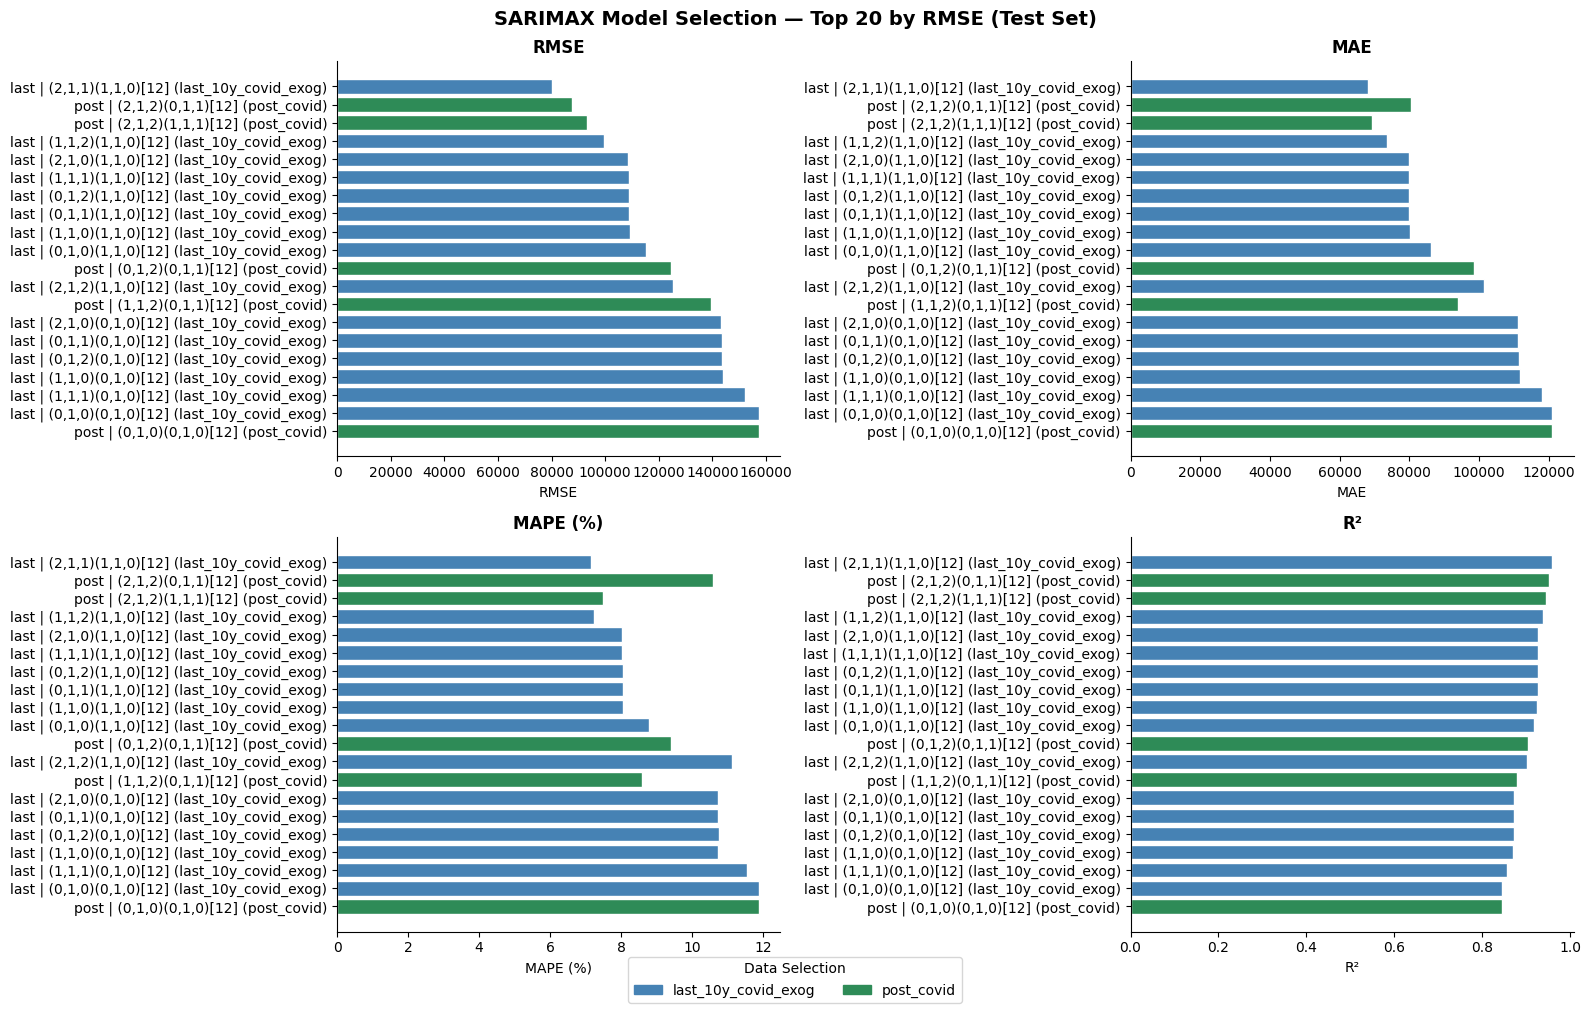

,data_selection,run_name,aic,bic,rmse,mae,mape,r2
0,last_10y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_exog)",239.813006,255.072774,80202.749743,67992.564131,7.157324,0.960139
1,post_covid,"SARIMAX(2,1,2)(0,1,1)[12] (post_covid)",-25.095212,-24.618563,87498.901223,80574.037078,10.592783,0.952556
2,post_covid,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid)",-26.858819,-26.302729,93076.777785,69293.253223,7.480396,0.946314
3,last_10y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_exog)",243.326194,258.649455,99552.650691,73451.207316,7.228299,0.938584
4,last_10y_covid_exog,"SARIMAX(2,1,0)(1,1,0)[12] (last_10y_covid_exog)",241.274768,253.991242,108690.040061,79812.108667,8.030331,0.926793
5,last_10y_covid_exog,"SARIMAX(1,1,1)(1,1,0)[12] (last_10y_covid_exog)",242.735447,255.504831,108764.947004,79852.244673,8.034462,0.926692
6,last_10y_covid_exog,"SARIMAX(0,1,2)(1,1,0)[12] (last_10y_covid_exog)",244.417704,257.239445,108902.140794,79973.374680,8.046043,0.926507
7,last_10y_covid_exog,"SARIMAX(0,1,1)(1,1,0)[12] (last_10y_covid_exog)",242.417709,252.675102,108907.987687,79978.357828,8.046387,0.926499
8,last_10y_covid_exog,"SARIMAX(1,1,0)(1,1,0)[12] (last_10y_covid_exog)",240.750643,250.966151,109224.385734,80204.064769,8.063683,0.926071
9,last_10y_covid_exog,"SARIMAX(0,1,0)(1,1,0)[12] (last_10y_covid_exog)",241.761862,249.454907,115184.929168,86332.392360,8.773657,0.917782


In [81]:
palette = {'last_10y_covid_exog': 'steelblue', 'post_covid': 'seagreen'}

top_n = results_df.head(20).copy()
top_n['label'] = (
    top_n['data_selection'].str[:4]
    + ' | '
    + top_n['run_name'].str.replace('SARIMAX', '', regex=False)
)
bar_colors = [palette[ds] for ds in top_n['data_selection'][::-1]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'SARIMAX Model Selection — Top 20 by RMSE (Test Set)',
    fontsize=14,
    fontweight='bold',
)

for ax, (col, title) in zip(
    axes.flat, [('rmse', 'RMSE'), ('mae', 'MAE'), ('mape', 'MAPE (%)'), ('r2', 'R²')]
):
    ax.barh(top_n['label'][::-1], top_n[col][::-1], color=bar_colors, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    sns.despine(ax=ax)

handles = [mpatches.Patch(color=c, label=k) for k, c in palette.items()]
fig.legend(
    handles=handles,
    title='Data Selection',
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.02),
)
plt.tight_layout()
plt.show()

display(
    results_df[
        ['data_selection', 'run_name', 'aic', 'bic', 'rmse', 'mae', 'mape', 'r2']
    ].head(10)
)

## Best Model Diagnostics

In [82]:
best_per_selection = (
    results_df
    .sort_values('rmse')
    .groupby('data_selection', sort=False)
    .first()
    .reset_index()
)

best_10y = best_per_selection[
    best_per_selection['data_selection'] == 'last_10y_covid_exog'
].iloc[0]
best_post = best_per_selection[
    best_per_selection['data_selection'] == 'post_covid'
].iloc[0]

display(
    best_per_selection[
        ['data_selection', 'run_name', 'aic', 'bic', 'rmse', 'mae', 'mape', 'r2']
    ]
)

,data_selection,run_name,aic,bic,rmse,mae,mape,r2
0,last_10y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_exog)",239.813006,255.072774,80202.749743,67992.564131,7.157324,0.960139
1,post_covid,"SARIMAX(2,1,2)(0,1,1)[12] (post_covid)",-25.095212,-24.618563,87498.901223,80574.037078,10.592783,0.952556


In [83]:
def fit_model(row, configs):
    cfg = configs[row['data_selection']]
    return SARIMAX(
        cfg['series'],
        exog=cfg['exog_train'],
        order=row['order'],
        seasonal_order=row['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)


fit_10y = fit_model(best_10y, data_configs)
fit_post = fit_model(best_post, data_configs)

print(f'[last_10y_covid_exog] {best_10y["run_name"]}')
print(
    f'  AIC={best_10y["aic"]:.2f}  BIC={best_10y["bic"]:.2f}  RMSE={best_10y["rmse"]:,.0f}  MAPE={best_10y["mape"]:.2f}%  R²={best_10y["r2"]:.4f}'
)
print()
print(f'[post_covid]          {best_post["run_name"]}')
print(
    f'  AIC={best_post["aic"]:.2f}  BIC={best_post["bic"]:.2f}  RMSE={best_post["rmse"]:,.0f}  MAPE={best_post["mape"]:.2f}%  R²={best_post["r2"]:.4f}'
)

[last_10y_covid_exog] SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_exog)
  AIC=239.81  BIC=255.07  RMSE=80,203  MAPE=7.16%  R²=0.9601

[post_covid]          SARIMAX(2,1,2)(0,1,1)[12] (post_covid)
  AIC=-25.10  BIC=-24.62  RMSE=87,499  MAPE=10.59%  R²=0.9526


In [84]:
fit_10y.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                       arrival_count   No. Observations:                  121
Model:             SARIMAX(2, 1, 1)x(1, 1, [], 12)   Log Likelihood                -113.907
Date:                             qua, 10 jun 2026   AIC                            239.813
Time:                                     20:58:01   BIC                            255.073
Sample:                                 12-31-2014   HQIC                           245.977
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_covid      -0.8779      0.519     -1.692      0.091      -1.895       0.139
ar.L1          1.0291      0.154      6.682      0.000       0.727       1.331
ar.L2         -0.2732      0.131     -2.087      0.037      -0.530      -0.017
ma.L1         -0.9529      0.075    -12.773      0.000      -1.099      -0.807
ar.S.L12      -0.4473      0.040    -11.251      0.000      -0.525      -0.369
sigma2         0.6557      0.045     14.699      0.000       0.568       0.743
===================================================================================
Ljung-Box (L1) (Q):                   0.30   Jarque-Bera (JB):              3053.02
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               2.56   Skew:                            -2.69
Prob(H) (two-sided):                  0.01   Kurtosis:                        30.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [85]:
fit_post.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                        arrival_count   No. Observations:                   36
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                  18.548
Date:                              qua, 10 jun 2026   AIC                            -25.095
Time:                                      20:58:01   BIC                            -24.619
Sample:                                  01-31-2022   HQIC                           -28.310
                                       - 12-31-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2689      0.229     -1.174      0.240      -0.718       0.180
ar.L2         -0.5645      0.118     -4.772      0.000      -0.796      -0.333
ma.L1         -0.0820      0.183     -0.448      0.654      -0.441       0.277
ma.L2          0.4721      0.333      1.416      0.157      -0.181       1.126
ma.S.L12      -1.0005    692.922     -0.001      0.999   -1359.103    1357.102
sigma2         0.0004      0.260      0.001      0.999      -0.509       0.510
===================================================================================
Ljung-Box (L1) (Q):                   0.98   Jarque-Bera (JB):                 3.25
Prob(Q):                              0.32   Prob(JB):                         0.20
Heteroskedasticity (H):               1.72   Skew:                            -1.41
Prob(H) (two-sided):                  0.67   Kurtosis:                         4.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Residual Diagnostics

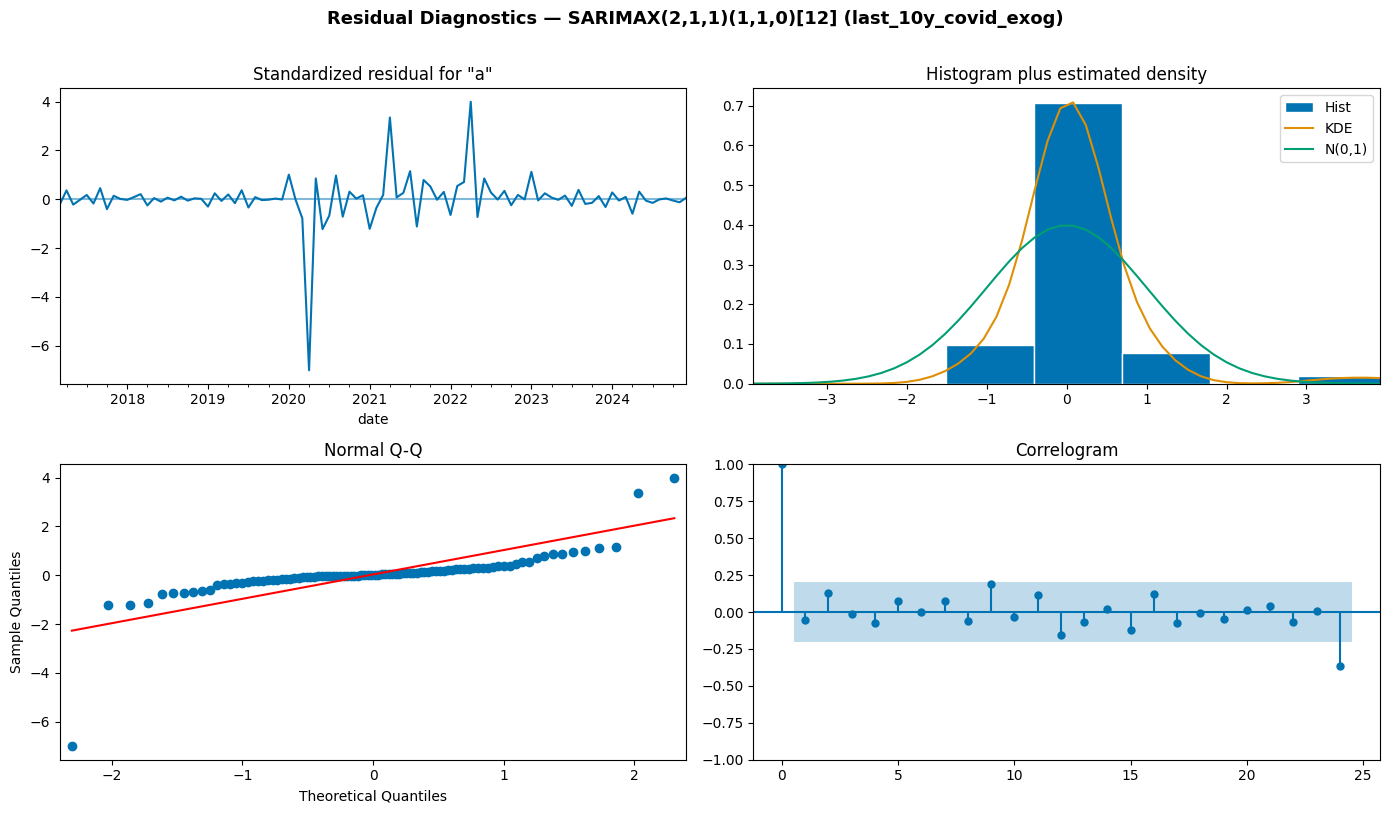

In [86]:
fig = fit_10y.plot_diagnostics(figsize=(14, 8), lags=24)
fig.suptitle(
    f'Residual Diagnostics — {best_10y["run_name"]}',
    fontsize=13,
    fontweight='bold',
    y=1.01,
)
plt.tight_layout()
plt.show()

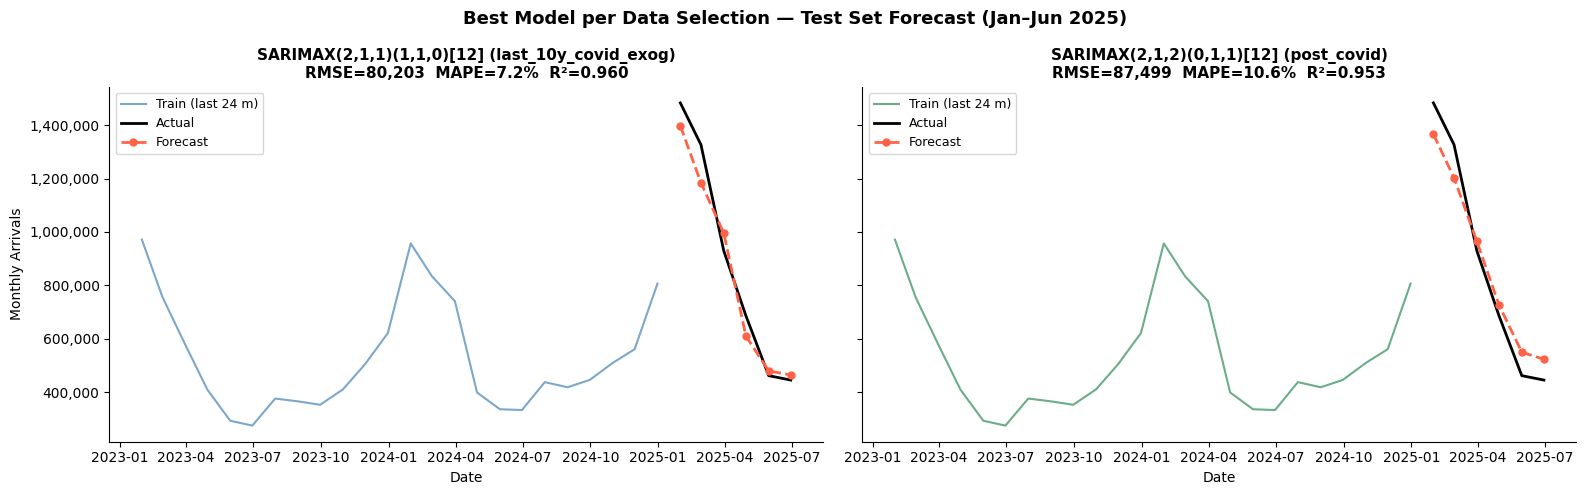

In [87]:
models = [
    (best_10y, fit_10y, data_configs['last_10y_covid_exog'], 'steelblue'),
    (best_post, fit_post, data_configs['post_covid'], 'seagreen'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (row, fit, cfg, color) in zip(axes, models):
    forecast_log = fit.forecast(steps=n_test, exog=cfg['exog_test'])
    forecast = np.exp(forecast_log)
    train_plot = np.exp(cfg['series']).iloc[-24:]

    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Train (last 24 m)',
        linewidth=1.5,
        color=color,
        alpha=0.7,
    )
    ax.plot(
        test_monthly.index,
        test_monthly['arrival_count'],
        label='Actual',
        linewidth=2,
        color='black',
    )
    ax.plot(
        test_monthly.index,
        forecast,
        label='Forecast',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )

    ax.set_title(
        f'{row["run_name"]}\n'
        f'RMSE={row["rmse"]:,.0f}  MAPE={row["mape"]:.1f}%  R²={row["r2"]:.3f}',
        fontsize=11,
        fontweight='bold',
    )
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

axes[0].set_ylabel('Monthly Arrivals')
fig.suptitle(
    'Best Model per Data Selection — Test Set Forecast (Jan–Jun 2025)',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()